In [65]:
import polars as pl
from matplotlib import pyplot as plt
from dataclasses import dataclass

In [73]:
from IPython.core.interactiveshell import InteractiveShell

# Set it to display all outputs, not just the last one
InteractiveShell.ast_node_interactivity = "all"


In [15]:
#fp_users = "/project/data/processed/train_no_eval_users_eval_local_events/shows_clicks_stats/user_id/part_000.parquet"
fp_users_local_eval_000 = "/project/data/raw/eval/local_events/part_000.pq"
df_users_local_eval_000 = pl.scan_parquet(fp_users_local_eval_000)

In [16]:
df_users_local_eval_000.select(pl.len()).collect()

len
u32
3988126


In [11]:
fp_items_dict = "/project/data/dict/item_features.parquet"
df_items_dict = pl.scan_parquet(fp_items_dict)

## subcatalog stats
### how many items are left in the catalog if we sample by top cat feature value for user

In [159]:
def f(df_):
    df_ = df_.filter(pl.col("a") < 2)


df = pl.DataFrame({"a": [1,2,3]})
f(df)
df

a
i64
1
2
3


In [ ]:
@dataclass
class SubCatalogStats:
    item_counts: pl.DataFrame
    item_counts_stats: pl.DataFrame

def subcatalog_size(df, cat_features, blacklist=None, do_plot=False):
    if isinstance(cat_features, str):
        cat_features = [cat_features]

    if blacklist is not None:
        df = df.join(blacklist, on="item_id", how="anti")

    item_count_by_cat = df.group_by(*cat_features).agg(pl.len().alias("cnt")).collect().sort(by="cnt")
    if do_plot:
        plt.figure(figsize=(1, 1))
        plt.plot(item_count_by_cat["cnt"])
        plt.title(f"subcatalog sizes by {cat_features}")
        plt.show()

    return SubCatalogStats(
        item_counts=item_count_by_cat,
        item_counts_stats=item_count_by_cat.select(
            pl.col("cnt").min().alias("min"),
            pl.col("cnt").max().alias("max"),
            pl.col("cnt").mean().alias("mean"),
            pl.col("cnt").median().alias("median"),
            pl.col("cnt").std().alias("std")
        )
    )

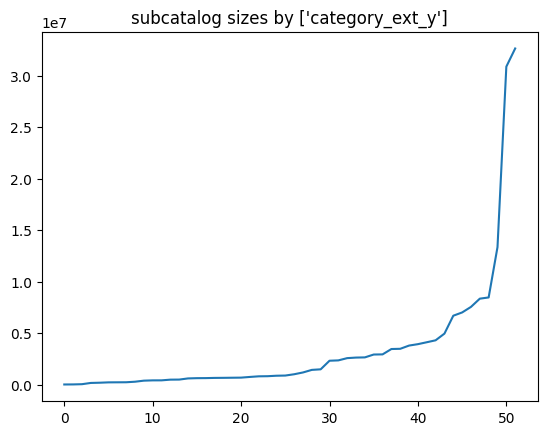

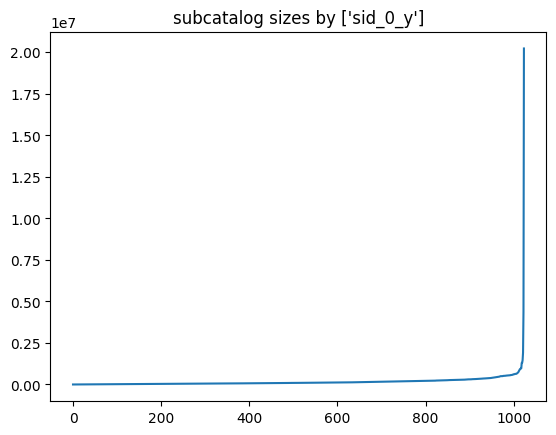

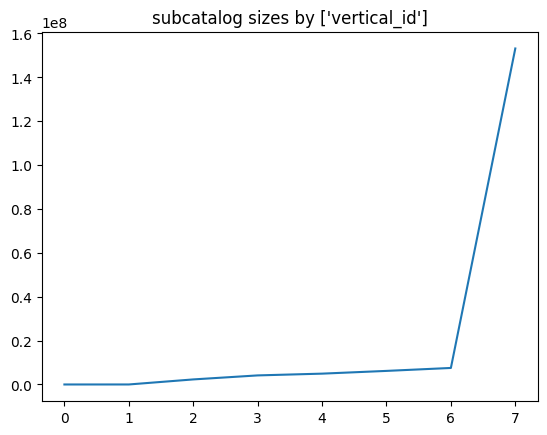

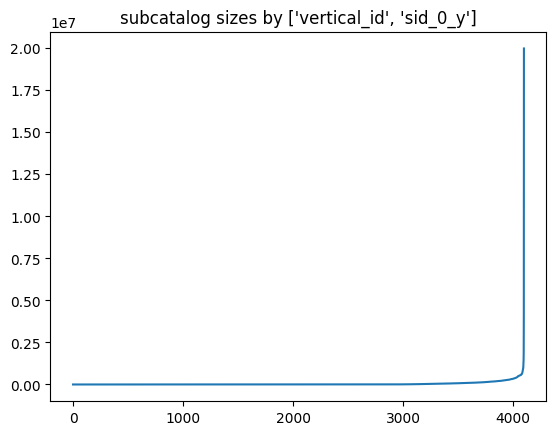

by_cat


min,max,mean,median,std
u32,u32,f64,f64,f64
8609,32631388,3.4294e6,938125.0,6.3427e6


by_sid0


min,max,mean,median,std
u32,u32,f64,f64,f64
12,20231544,174148.104492,96978.5,663669.311162


by_vertical_id


min,max,mean,median,std
u32,u32,f64,f64,f64
8609,153162868,2.2291e7,4545043.5,5.2950e7


by_vertical_id_sid0


min,max,mean,median,std
u32,u32,f64,f64,f64
1,19986130,43505.161991,168.0,335044.750191


In [161]:
subcat_by_cat = subcatalog_size(df_items_dict, "category_ext_y")
subcat_by_sid0 = subcatalog_size(df_items_dict, "sid_0_y")
subcat_by_vertical_id = subcatalog_size(df_items_dict, "vertical_id")
subcat_by_vertical_id_sid0 = subcatalog_size(df_items_dict, ["vertical_id", "sid_0_y"])

print("by_cat")
subcat_by_cat.item_counts_stats
print("by_sid0")
subcat_by_sid0.item_counts_stats
print("by_vertical_id")
subcat_by_vertical_id.item_counts_stats
print("by_vertical_id_sid0")
subcat_by_vertical_id_sid0.item_counts_stats

In [162]:
subcat_by_cat.item_counts
subcat_by_sid0.item_counts
subcat_by_vertical_id.item_counts
subcat_by_vertical_id_sid0.item_counts

category_ext_y,cnt
i64,u32
51,8609
50,14042
29,36121
7,157668
34,179565
…,…
4,8340775
5,8458239
13,13342147


sid_0_y,cnt
i64,u32
510,12
233,211
854,329
297,673
865,998
…,…
111,1302133
567,1462943
588,1914444


vertical_id,cnt
u32,u32
1,8609
6,14042
7,2313893
5,4143039
2,4947048
3,6197510
4,7540650
0,153162868


vertical_id,sid_0_y,cnt
u32,i64,u32
5,656,1
7,527,1
2,981,1
7,379,1
7,536,1
…,…,…
0,111,1302089
0,567,1460613
0,588,1909646


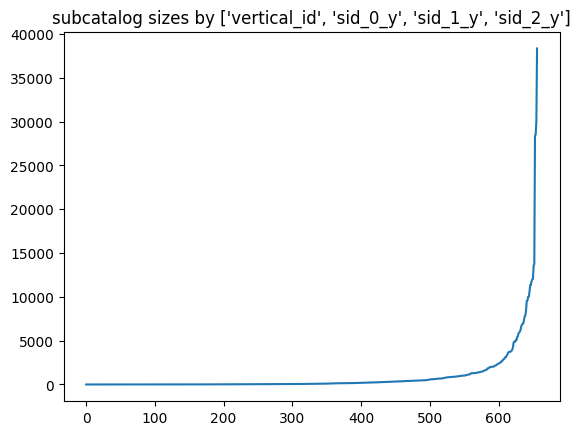

vertical_id,sid_0_y,sid_1_y,sid_2_y,cnt
u32,i64,i64,i64,u32
0,404,491,457,11356
0,404,491,24,11765
0,404,491,87,11996
0,404,491,201,12060
0,404,491,474,13564
0,404,491,852,13745
0,404,491,722,28366
0,404,491,144,28552
0,404,491,159,29982


In [116]:
### vid = 0, sid0=404 separately:
subcat_vid_0 = subcatalog_size(df_items_dict.filter(pl.col("vertical_id") == 0, pl.col("sid_0_y") == 404, pl.col("sid_1_y") == 491), ["vertical_id", "sid_0_y", "sid_1_y", "sid_2_y"])
subcat_vid_0.item_counts.tail(n=10)

#### now the same but after blacklisting items by min_shows, min_clicks

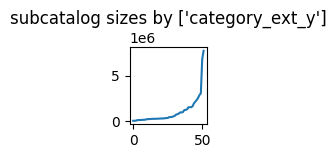

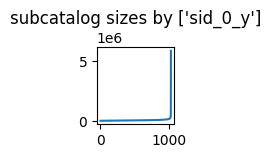

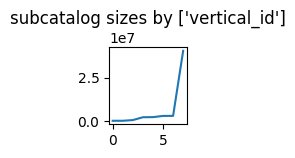

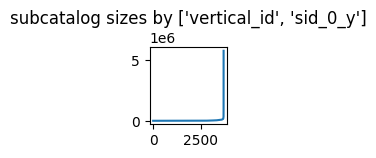

min,max,mean,median,std
u32,u32,f64,f64,f64
1397,7757988,979674.365385,352815.5,1.4998e6


min,max,mean,median,std
u32,u32,f64,f64,f64
6,5833662,49749.088867,31631.0,190584.041485


min,max,mean,median,std
u32,u32,f64,f64,f64
1397,40681109,6.3679e6,2089441.5,1.3916e7


min,max,mean,median,std
u32,u32,f64,f64,f64
1,5749559,13764.676304,108.0,100824.49771


In [165]:
df_bl_min = pl.scan_parquet("/project/data/processed/train_no_eval_users_eval_local_events/shows_clicks_stats/item_blacklist_shows_10_clicks_1.parquet")

subcat_by_cat = subcatalog_size(df_items_dict, "category_ext_y", blacklist=df_bl_min)
subcat_by_sid0 = subcatalog_size(df_items_dict, "sid_0_y", blacklist=df_bl_min)
subcat_by_vertical_id = subcatalog_size(df_items_dict, "vertical_id", blacklist=df_bl_min)
subcat_by_vertical_id_sid0 = subcatalog_size(df_items_dict, ["vertical_id", "sid_0_y"], blacklist=df_bl_min)

subcat_by_cat.item_counts_stats
subcat_by_sid0.item_counts_stats
subcat_by_vertical_id.item_counts_stats
subcat_by_vertical_id_sid0.item_counts_stats

In [84]:
subcat_by_cat.item_counts
subcat_by_sid0.item_counts
subcat_by_vertical_id.item_counts

category_ext_y,cnt
i64,u32
51,1397
50,2885
29,12179
2,72481
17,79387
…,…
4,2532406
48,2855381
13,3041779


sid_0_y,cnt
i64,u32
510,6
854,62
233,64
297,141
865,298
…,…
188,319464
567,346864
588,509317


vertical_id,cnt
u32,u32
1,1397
6,2885
7,410721
5,2059243
2,2119640
3,2812691
4,2855381
0,40681109


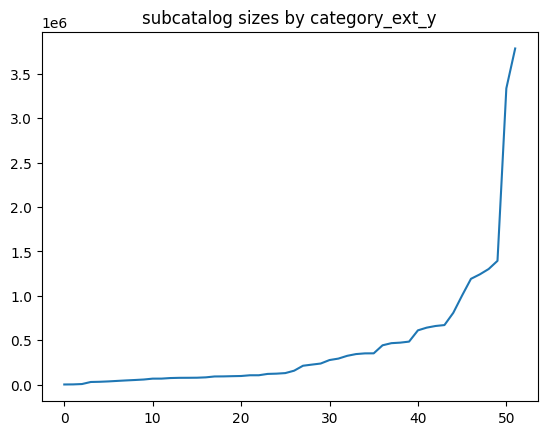

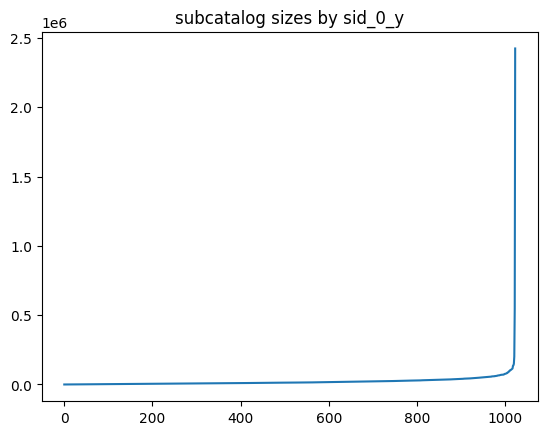

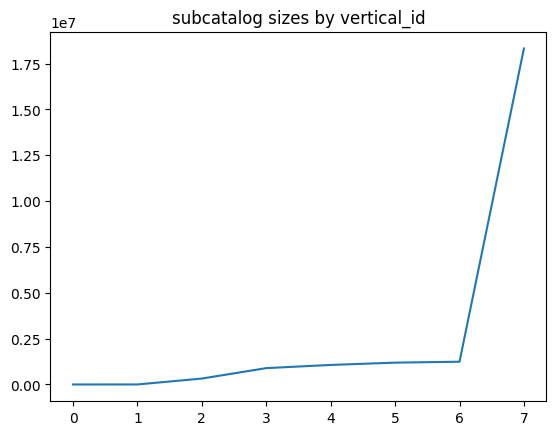

min,max,mean,median,std
u32,u32,f64,f64,f64
430,3787241,443003.673077,142323.0,728036.553038


min,max,mean,median,std
u32,u32,f64,f64,f64
2,2424465,22496.280273,13527.0,79579.48308


min,max,mean,median,std
u32,u32,f64,f64,f64
430,18320632,2.8795e6,978968.0,6.2599e6


In [85]:
blacklist_items_mid = pl.scan_parquet("/project/data/processed/train_no_eval_users_eval_local_events/shows_clicks_stats/item_blacklist_shows_50_clicks_5.parquet")

subcat_by_cat = subcatalog_size(df_items_dict.join(blacklist_items_mid, on=["item_id"], how="anti"), "category_ext_y")
subcat_by_sid0 = subcatalog_size(df_items_dict.join(blacklist_items_mid, on=["item_id"], how="anti"), "sid_0_y")
subcat_by_vertical_id = subcatalog_size(df_items_dict.join(blacklist_items_mid, on=["item_id"], how="anti"), "vertical_id")

subcat_by_cat.item_counts_stats
subcat_by_sid0.item_counts_stats
subcat_by_vertical_id.item_counts_stats

In [86]:
subcat_by_cat.item_counts
subcat_by_sid0.item_counts
subcat_by_vertical_id.item_counts

category_ext_y,cnt
i64,u32
50,430
51,1335
29,5351
35,28525
2,30793
…,…
46,1241356
4,1301627
13,1393980


sid_0_y,cnt
i64,u32
510,2
854,16
233,52
297,54
865,147
…,…
567,138141
962,148846
588,202175


vertical_id,cnt
u32,u32
6,430
1,1335
7,323316
5,892219
3,1065717
4,1191186
2,1241356
0,18320632


## recalls by leaving only items form top-k cat feature values

In [ ]:
# fp = "/project/data/processed/train_no_eval_users_eval_local_events/shows_clicks_stats/item_id/r*_part_0*.parquet"
# df_items_shows_clicks = pl.scan_parquet(fp)
# df_items_shows_clicks = df_items_shows_clicks.group_by("item_id").agg(
#     pl.col("events_cnt_by_item_id").sum(),
#     pl.col("clicks_cnt_by_item_id").sum(),
# )

In [121]:
CONTACT_EIDS = [0, 2, 4, 5, 6, 8, 9, 11, 14, 15, 16]

def count_shows_clicks(df):
    return df.group_by("user_id").agg(
        pl.len().alias("events_cnt"),
        pl.col("is_click").sum().alias("clicks_cnt")
    )

def plot_recalls(recalls, col="events"):
    assert col in ["events", "clicks"]
    plt.hist(recalls.select(pl.col(f"{col}_recall")).drop_nans().collect())
    plt.title(col)
    plt.show()

def top_k_cat_counts(df_events_, df_items, cat_columns, k=3, sort_by="events"):
    assert sort_by in ["events", "clicks"]
    if isinstance(cat_columns, str):
        cat_columns = [cat_columns]

    counts_by_user = (
        df_events_.join(df_items.select(["item_id", *cat_columns]), on="item_id").with_columns(
            (pl.col("eid").is_in(CONTACT_EIDS)).alias("is_click")
        )   
        .group_by("user_id", *cat_columns)
        .agg(
            pl.len().alias("cnt_events_by_user_cat_columns"),
            pl.col("is_click").sum().alias("cnt_clicks_by_user_cat_columns"),
        )
        .sort(by=["user_id", f"cnt_{sort_by}_by_user_cat_columns"], descending=True)
    )
    
    top_k_category_counts = counts_by_user.group_by(["user_id"], maintain_order=True).head(k)

    return top_k_category_counts
    

def recall_if_leave_top_k_cat_values(df_events_, cat_columns, df_items, k=3, sort_by="events", blacklist=None, slice_filters=None):
    assert sort_by in ["events", "clicks"]
    if isinstance(cat_columns, str):
        cat_columns = [cat_columns]

    top_k_category_counts = top_k_cat_counts(df_events_, df_items, cat_columns, k=k, sort_by=sort_by)
    df_events = df_events_.join(df_items.select(["item_id", *cat_columns]), on="item_id").with_columns(
            (pl.col("eid").is_in(CONTACT_EIDS)).alias("is_click")
    )   
    
    df_events_top_k_cats = df_events.join(top_k_category_counts, on=["user_id", *cat_columns], how="semi")
    if blacklist is not None:
        df_events_top_k_cats = df_events_top_k_cats.join(blacklist, on="item_id", how="anti")

    ###
    # select slice of users that have a specific set of categories as their top
    if slice_filters is not None:
        users_slice = top_k_category_counts.filter(slice_filters).select("user_id")
        df_events = df_events.join(users_slice, on="user_id", how="semi")
        df_events_top_k_cats = df_events_top_k_cats.join(users_slice, on="user_id", how="semi")

    df_shows_clicks = count_shows_clicks(df_events)
    df_shows_clicks_top_k = count_shows_clicks(df_events_top_k_cats)

    recalls = df_shows_clicks.join(df_shows_clicks_top_k, on=["user_id"], suffix="_top_cat").select(
        pl.col("user_id"),
        (pl.col("events_cnt_top_cat") / pl.col("events_cnt")).alias("events_recall"),
        (pl.col("clicks_cnt_top_cat") / pl.col("clicks_cnt")).alias("clicks_recall"),
    )
    recalls_stats = recalls.select(
        (pl.col("events_recall").is_nan().sum() / pl.col("events_recall").len()).alias("nan_share_events"),
        (pl.col("clicks_recall").is_nan().sum() / pl.col("clicks_recall").len()).alias("nan_share_clicks"),
        pl.col("events_recall").fill_nan(0).mean().alias("mean_events_recall_filled"),
        pl.col("clicks_recall").fill_nan(0).mean().alias("mean_clicks_recall_filled"),
        pl.col("events_recall").drop_nans().mean().alias("mean_events_recall_dropped"),
        pl.col("clicks_recall").drop_nans().mean().alias("mean_clicks_recall_dropped"),
    )

    return recalls, recalls_stats

In [123]:
df_events_000 = pl.scan_parquet("/project/data/raw/eval/local_events/part_000.pq")

fp_bl_mid = "/project/data/processed/train_no_eval_users_eval_local_events/shows_clicks_stats/item_blacklist_shows_50_clicks_5.parquet"
df_bl_mid = pl.scan_parquet(fp_bl_mid)

fp_bl_min = "/project/data/processed/train_no_eval_users_eval_local_events/shows_clicks_stats/item_blacklist_shows_10_clicks_1.parquet"
df_bl_min = pl.scan_parquet(fp_bl_min)

df_events_000 = df_events_000.join(df_items_dict, on="item_id")#.join(df_items_shows_clicks, on="item_id")
df_events_000.select(pl.len()).collect()

len
u32
3988126


nan_share_events,nan_share_clicks,mean_events_recall_filled,mean_clicks_recall_filled,mean_events_recall_dropped,mean_clicks_recall_dropped
f64,f64,f64,f64,f64,f64
0.0,0.086772,0.410313,0.705481,0.410313,0.772514


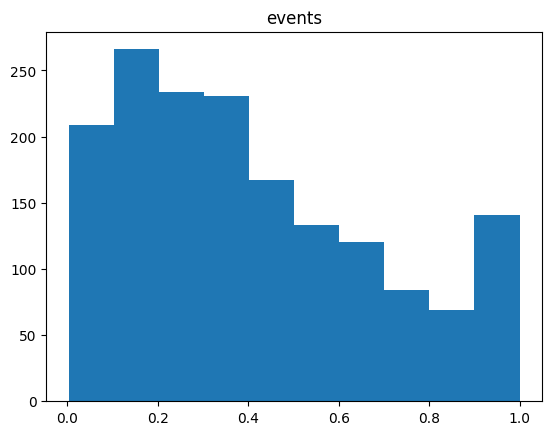

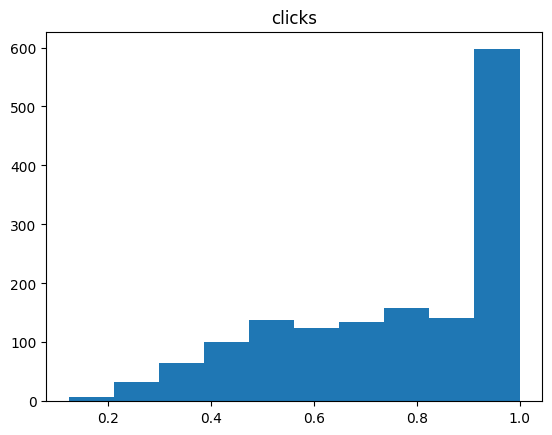

In [158]:
recalls, recalls_stats = recall_if_leave_top_k_cat_values(
    df_events_000,
    ["vertical_id", "loc_id_y", "category_ext_y"],
    # ["vertical_id"],
    df_items_dict,
    k=3,
    sort_by="clicks",
    # blacklist=df_bl_min,
    slice_filters=[pl.col("vertical_id") != 0]
    # slice_filters=[pl.col("vertical_id") != 0, pl.col("sid_0_y") != 404]
    # slice_filters=[pl.col("vertical_id") == 0, pl.col("sid_0_y") == 404]
)
recalls_stats.collect()
plot_recalls(recalls, col="events")
plot_recalls(recalls, col="clicks")

In [19]:
df_users_local_eval_000.head().collect()

timestamp,eid,user_id,item_id,vertical_id,category_ext_y,region_id_y,loc_id_y,sid_0_y,sid_1_y,sid_2_y,sid_3_y,events_cnt_by_item_id,clicks_cnt_by_item_id,vertical_id_right,category_ext_y_right,region_id_y_right,loc_id_y_right,sid_0_y_right,sid_1_y_right,sid_2_y_right,sid_3_y_right,events_cnt_by_item_id_right,clicks_cnt_by_item_id_right
i64,u32,u32,u32,u32,i64,i64,i64,i64,i64,i64,i64,u32,u32,u32,i64,i64,i64,i64,i64,i64,i64,u32,u32
1773535350000,7,4005100,101011768,0,11,35,1460,136,822,280,289,124,1,0,11,35,1460,136,822,280,289,124,1
1769085366000,7,5305900,27929463,0,42,34,1412,565,643,811,536,807,27,0,42,34,1412,565,643,811,536,807,27
1769327243000,7,5305900,27929463,0,42,34,1412,565,643,811,536,807,27,0,42,34,1412,565,643,811,536,807,27
1769507313000,7,5305900,27929463,0,42,34,1412,565,643,811,536,807,27,0,42,34,1412,565,643,811,536,807,27
1769307775000,7,6197200,111858362,0,11,34,1412,178,542,536,305,85,4,0,11,34,1412,178,542,536,305,85,4


In [30]:
category_counts_by_user = df_users_local_eval_000.group_by("user_id", "category_ext_y").agg(pl.len().alias("cnt_events_by_user_category")).sort(by=["user_id", "cnt_events_by_user_category"], descending=True)
category_counts_by_user.collect()

user_id,category_ext_y,cnt_events_by_user_category
u32,i64,u32
8426800,1,32
8426800,0,21
8426800,12,6
8426800,48,3
8426800,46,2
…,…,…
2600,30,3
2600,21,3
2600,23,2


In [63]:
top_3_category_counts = category_counts_by_user.group_by(["user_id"], maintain_order=True).head(3)
top_2_category_counts = category_counts_by_user.group_by(["user_id"], maintain_order=True).head(2)
top_1_category_counts = category_counts_by_user.group_by(["user_id"], maintain_order=True).head(1)

In [39]:
df_users_events_top_3_cats = df_users_local_eval_000.join(top_3_category_counts, on=["user_id", "category_ext_y"], how="semi")
df_users_events_top_3_cats.select(pl.len()).collect()

len
u32
3130662


In [61]:
def count_shows_clicks(df):
    return df.group_by("user_id").agg(
        pl.len().alias("events_cnt"),
        (pl.col("eid").is_in([0, 2, 4, 5, 6, 8, 9, 11, 14, 15, 16])).sum().alias("clicks_cnt")
    )

df_shows_clicks = count_shows_clicks(df_users_local_eval_000)
df_shows_clicks_top_3 = count_shows_clicks(df_users_events_top_3_cats)

df_shows_clicks.join(df_shows_clicks_top_3, on=["user_id"], suffix="_top_cat").select(
    (pl.col("events_cnt_top_cat") / pl.col("events_cnt")).alias("events_recall"),
    (pl.col("clicks_cnt_top_cat") / pl.col("clicks_cnt")).alias("clicks_recall"),
).drop_nans().mean().collect()

events_recall,clicks_recall
f64,f64
0.799576,0.811107


In [64]:
df_users_events_top_2_cats = df_users_local_eval_000.join(top_2_category_counts, on=["user_id", "category_ext_y"], how="semi")
df_shows_clicks_top_2 = count_shows_clicks(df_users_events_top_2_cats)

df_shows_clicks.join(df_shows_clicks_top_2, on=["user_id"], suffix="_top_cat").select(
    (pl.col("events_cnt_top_cat") / pl.col("events_cnt")).alias("events_recall"),
    (pl.col("clicks_cnt_top_cat") / pl.col("clicks_cnt")).alias("clicks_recall"),
).drop_nans().mean().collect()

events_recall,clicks_recall
f64,f64
0.705073,0.704703


In [62]:
df_users_events_top_1_cats = df_users_local_eval_000.join(top_1_category_counts, on=["user_id", "category_ext_y"], how="semi")
df_shows_clicks_top_1 = count_shows_clicks(df_users_events_top_1_cats)

df_shows_clicks.join(df_shows_clicks_top_1, on=["user_id"], suffix="_top_cat").select(
    (pl.col("events_cnt_top_cat") / pl.col("events_cnt")).alias("events_recall"),
    (pl.col("clicks_cnt_top_cat") / pl.col("clicks_cnt")).alias("clicks_recall"),
).drop_nans().mean().collect()

events_recall,clicks_recall
f64,f64
0.526364,0.519575


In [44]:
df_shows_clicks.filter(pl.col("user_id") == 2600).collect()

user_id,events_cnt,clicks_cnt
u32,u32,u32
2600,201,2


# blacklist + show_cnt_percentiles

In [14]:
fp_bl_min = "/project/data/processed/train_no_eval_users_eval_local_events/shows_clicks_stats/item_blacklist_shows_10_clicks_1.parquet"
df_bl_min = pl.scan_parquet(fp_bl_min)
df_bl_min.head().collect()

item_id,events_cnt_by_item_id,clicks_cnt_by_item_id
u32,u32,u32
48040000,15,0
831300,3,0
45005100,19,0
60230300,3,0
145326200,28,0


In [15]:
df_bl_min.select(
    pl.len().alias("cnt"),
    pl.n_unique("item_id").alias("cnt_unique")
).collect()

cnt,cnt_unique
u32,u32
127384592,127384592


In [16]:
df_items_000_whitelisted = df_items_000.join(df_bl_min, on="item_id", how="anti")
df_items_000_whitelisted.select(pl.len()).collect()

len
u32
339293


In [17]:
fp_bl_mid = "/project/data/processed/train_no_eval_users_eval_local_events/shows_clicks_stats/item_blacklist_shows_50_clicks_5.parquet"
df_bl_mid = pl.scan_parquet(fp_bl_mid)

df_bl_mid.select(
    pl.len().alias("cnt"),
    pl.n_unique("item_id").alias("cnt_unique")
).collect()

cnt,cnt_unique
u32,u32
155291468,155291468


In [18]:
df_items_000_whitelisted_mid = df_items_000.join(df_bl_mid, on="item_id", how="anti")
df_items_000_whitelisted_mid.select(pl.len()).collect()

len
u32
59666


In [31]:
qs = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
# qs = [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]

events_qs = [pl.quantile("events_cnt_by_item_id", q).alias(f"q_{int(100*q):02d}") for q in qs]
clicks_qs = [pl.quantile("clicks_cnt_by_item_id", q).alias(f"q_{int(100*q):02d}") for q in qs]

df_items_000.select(
    *events_qs
).collect()

q_01,q_05,q_10,q_20,q_30,q_40,q_50,q_60,q_70,q_80,q_90,q_95,q_99
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,1.0,1.0,1.0,2.0,4.0,6.0,9.0,15.0,28.0,62.0,116.0,373.0


In [32]:
df_items_000.select(
    *clicks_qs
).collect()

q_01,q_05,q_10,q_20,q_30,q_40,q_50,q_60,q_70,q_80,q_90,q_95,q_99
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,4.0,12.0


In [29]:
events_qs = [pl.quantile("events_cnt_by_user_id", q).alias(f"q_{int(100*q):02d}") for q in qs]
clicks_qs = [pl.quantile("clicks_cnt_by_user_id", q).alias(f"q_{int(100*q):02d}") for q in qs]

df_users_000.select(
    *events_qs
).collect()

q_01,q_05,q_10,q_20,q_30,q_40,q_50,q_60,q_70,q_80,q_90,q_95,q_99
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
3.0,10.0,20.0,48.0,88.0,143.0,222.0,340.0,519.0,817.0,1460.0,2272.0,5009.0


In [30]:
df_users_000.select(
    *clicks_qs
).collect()

q_01,q_05,q_10,q_20,q_30,q_40,q_50,q_60,q_70,q_80,q_90,q_95,q_99
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,1.0,1.0,2.0,3.0,4.0,6.0,8.0,13.0,20.0,38.0,64.0,165.0


In [ ]:
fp_items_dict = "/project/data/dict/item_features.parquet"
df_items_dict = pl.scan_parquet(fp_items_dict)
df_items_dict.select(
    pl.col("sid_0_y").n_unique(),
    pl.col("sid_1_y").n_unique(),
    pl.col("sid_2_y").n_unique(),
    pl.col("sid_3_y").n_unique(),
).collect()

sid_0_y,sid_1_y,sid_2_y,sid_3_y
u32,u32,u32,u32
1024,1024,1024,1024


In [37]:
df_items_dict.select(pl.col("category_ext_y").n_unique()).collect()

category_ext_y
u32
52


In [39]:
df_items_000_features = df_items_000.join(df_items_dict, on="item_id").collect()
df_items_000_features

item_id,events_cnt_by_item_id,clicks_cnt_by_item_id,vertical_id,category_ext_y,region_id_y,loc_id_y,sid_0_y,sid_1_y,sid_2_y,sid_3_y
u32,u32,u32,u32,i64,i64,i64,i64,i64,i64,i64
2700,4480,0,4,48,63,2793,368,166,55,870
20400,20,0,0,12,34,1412,247,405,140,485
29100,239,6,3,23,68,3182,922,411,447,571
37400,37,3,4,48,28,1165,359,950,888,834
43700,277,9,3,8,60,2675,756,505,885,71
…,…,…,…,…,…,…,…,…,…,…
178328000,1,0,0,19,73,3388,107,1006,788,1018
178327900,1,0,0,13,34,1412,180,823,908,379
178328600,1,0,0,16,45,2006,404,873,565,807


In [43]:
ctr_stds = df_items_000_features.with_columns(
    (pl.col("clicks_cnt_by_item_id") / pl.col("events_cnt_by_item_id")).alias("ctr")
).group_by("category_ext_y").agg(pl.col("ctr").std().alias("ctr_std"))

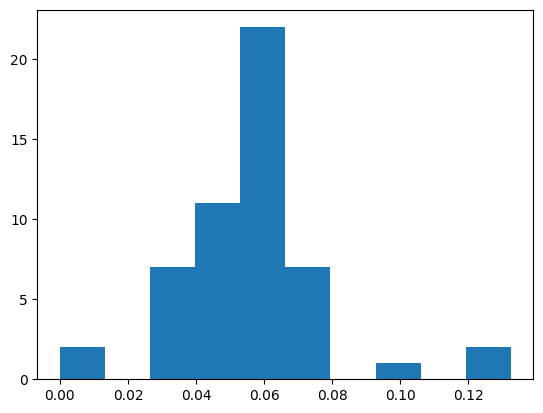

In [44]:
from matplotlib import pyplot as plt

plt.hist(ctr_stds["ctr_std"])
plt.show()